In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

pd.options.display.float_format = '{:,.2f}'.format

# E-Commerce Customer Behavior Analysis

## Section 1 - Project Overview

This project explores customer purchasing behavior in an e-commerce dataset. 
The objective of the analysis is to identify patterns in customer orders, product popularity, and reorder behavior.

Through exploratory data analysis and data visualization, the project aims to uncover insights about how customers interact with an online retail platform, including when they place orders, which products are most frequently purchased, and which items show higher customer loyalty.

The results of this analysis can help businesses better understand purchasing trends and support data-driven decision making in areas such as inventory management, marketing strategies, and customer retention.

## Tools Used

Python
pandas
NumPy
Matplotlib

## Section 2 -  Business Understanding

E-commerce platforms generate large volumes of transactional data that can provide valuable insights into customer purchasing behavior. By analyzing this data, businesses can better understand how customers interact with their platform, which products are most popular, and how purchasing patterns evolve over time.

Understanding customer behavior is essential for improving several aspects of an online retail business, including inventory planning, marketing strategies, product recommendations, and customer retention.

### Analysis Objectives

The main objective of this project is to explore customer purchasing patterns within an e-commerce dataset in order to identify meaningful trends and behaviors.

Through exploratory data analysis, this project aims to uncover patterns related to product popularity, purchasing timing, and customer loyalty.

### Key Questions

- Which products are purchased most frequently?
- Which departments generate the highest number of orders?
- At what time of the day do customers place the most orders?
- On which days of the week is purchasing activity highest?
- Which products have the highest reorder rates?
- How frequently do customers place new orders?

## Section 3 - Data Understanding

In this section, we explore the structure and contents of the dataset to gain a better understanding of the available information.

The goal of this step is to examine the dataset's size, variables, and basic characteristics before performing deeper analysis.

By inspecting the dataset, we can identify the types of variables available, understand how the data is organized, and detect potential data quality issues such as missing values.

In [3]:
df_raw = pd.read_csv("ECommerce_consumer behaviour.csv", delimiter = ',')
df_raw.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
0,2425083,49125,1,2,18,NaN,17,1,0,13,pantry,baking ingredients
1,2425083,49125,1,2,18,NaN,91,2,0,16,dairy eggs,soy lactosefree
2,2425083,49125,1,2,18,NaN,36,3,0,16,dairy eggs,butter
3,2425083,49125,1,2,18,NaN,83,4,0,4,produce,fresh vegetables
4,2425083,49125,1,2,18,NaN,83,5,0,4,produce,fresh vegetables


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019501 entries, 0 to 2019500
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   order_number            int64  
 3   order_dow               int64  
 4   order_hour_of_day       int64  
 5   days_since_prior_order  float64
 6   product_id              int64  
 7   add_to_cart_order       int64  
 8   reordered               int64  
 9   department_id           int64  
 10  department              object 
 11  product_name            object 
dtypes: float64(1), int64(9), object(2)
memory usage: 184.9+ MB


The dataset contains over 2 million rows and 12 columns.

Most variables are numerical identifiers related to orders and users, while two columns represent categorical variables describing product names and departments.

The column "days_since_prior_order" contains some missing values, which likely correspond to the first order placed by each customer.

In [5]:
df_raw.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id
count,"2,019,501.00","2,019,501.00","2,019,501.00","2,019,501.00","2,019,501.00","1,895,159.00","2,019,501.00","2,019,501.00","2,019,501.00","2,019,501.00"
mean,"1,707,012.76","103,067.27",17.15,2.74,13.44,11.39,71.21,8.36,0.59,9.93
std,"985,983.20","59,491.17",17.53,2.09,4.24,8.97,38.21,7.15,0.49,6.28
min,10.00,2.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00
25%,"852,649.00","51,584.00",5.00,1.00,10.00,5.00,31.00,3.00,0.00,4.00
50%,"1,705,004.00","102,690.00",11.00,3.00,13.00,8.00,83.00,6.00,1.00,9.00
75%,"2,559,031.00","154,600.00",24.00,5.00,16.00,15.00,107.00,11.00,1.00,16.00
max,"3,421,080.00","206,209.00",100.00,6.00,23.00,30.00,134.00,137.00,1.00,21.00


The column "days_since_prior_order" contains some missing values, which likely correspond to the first order placed by each customer.

The dataset contains information about customer ordering behavior.

Customers place an average of approximately 17 orders, with some users reaching up to 100 orders.

The average time between orders is around 11 days, suggesting relatively frequent purchasing patterns.

Additionally, the reorder rate is relatively high, indicating that customers frequently repurchase the same products.

In [6]:
df_raw.isnull().sum()

order_id                       0
user_id                        0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    124342
product_id                     0
add_to_cart_order              0
reordered                      0
department_id                  0
department                     0
product_name                   0
dtype: int64

### Missing Values Analysis

The dataset contains missing values only in the column **days_since_prior_order**.

These missing values likely correspond to the first order placed by each customer. Since there is no previous order, the number of days since the prior order cannot be calculated.

Therefore, these missing values are expected and do not indicate a data quality issue.

## Section 4 - Data Preparation

Before starting the exploratory analysis, a working copy of the dataset is created in order to preserve the original raw data.

At this stage, no major cleaning transformations are required, since the dataset is already well-structured and the only missing values appear in `days_since_prior_order`, which are expected for customers placing their first order.

This preparation step ensures that any future transformations or feature engineering can be performed safely without modifying the raw dataset.

In [7]:
df = df_raw.copy()
df.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
0,2425083,49125,1,2,18,NaN,17,1,0,13,pantry,baking ingredients
1,2425083,49125,1,2,18,NaN,91,2,0,16,dairy eggs,soy lactosefree
2,2425083,49125,1,2,18,NaN,36,3,0,16,dairy eggs,butter
3,2425083,49125,1,2,18,NaN,83,4,0,4,produce,fresh vegetables
4,2425083,49125,1,2,18,NaN,83,5,0,4,produce,fresh vegetables


## Section 5 - Exploratory Data Analysis

### Most Frequently Purchased Product Types

In this section, we examine which product types appear most frequently in customer purchases.

This analysis helps identify the categories that drive the highest transaction volume and provides insight into the core shopping behavior on the platform.

In [8]:
top_product_types = (
    df['product_name']
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)
top_product_types

product_name
bread                             36381
soy lactosefree                   39389
chips pretzels                    45306
water seltzer sparkling water     52564
milk                              55150
packaged cheese                   61502
yogurt                            90751
packaged vegetables fruits       109596
fresh vegetables                 212611
fresh fruits                     226039
Name: count, dtype: int64

The results show that fresh foods dominate the purchasing frequency.

Fresh fruits and fresh vegetables appear as the most purchased products, followed by dairy products such as yogurt and milk, as well as staple products like bread.

This suggests that customers primarily use this platform to purchase fresh groceries and frequently consumed food items.

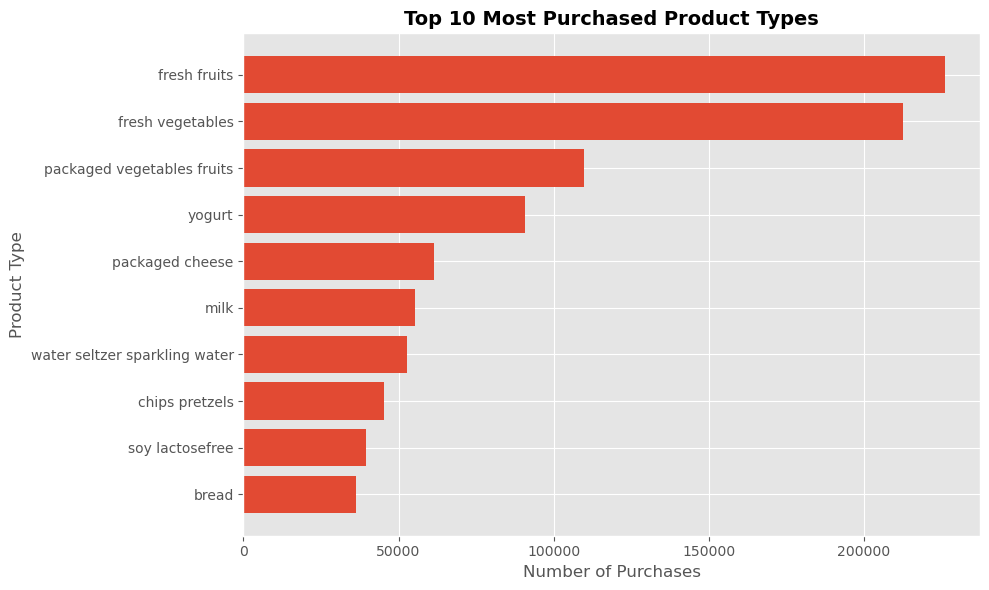

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(top_product_types.index, top_product_types.values)

plt.title("Top 10 Most Purchased Product Types", fontsize=14, fontweight="bold")
plt.xlabel("Number of Purchases", fontsize=12)
plt.ylabel("Product Type", fontsize=12)

plt.tight_layout()
plt.savefig("01_top_product_types.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The chart shows that fresh fruits and fresh vegetables are the most frequently purchased product types in the dataset, clearly standing out from the rest of the top 10.

This pattern suggests that customers mainly use the platform for recurring grocery shopping, with fresh and frequently consumed items representing a large share of total demand.

From a business perspective, these results highlight the importance of maintaining product availability and operational efficiency in high-demand fresh categories, since stock issues in these segments could directly affect customer satisfaction and repeat purchases.

## Customer Purchase Timing Analysis

### Order Distribution by Hour of Day

In this section, we analyze how customer order activity is distributed throughout the day.

Since each row in the dataset represents a product within an order, it is necessary to count unique orders rather than total rows to accurately measure purchasing activity over time.

In [11]:
orders_by_hour = (df.groupby('order_hour_of_day')['order_id'].nunique().sort_index())
orders_by_hour

order_hour_of_day
0      1311
1       719
2       429
3       287
4       330
5       555
6      1803
7      5310
8     10294
9     14989
10    17102
11    16748
12    15942
13    16189
14    16600
15    16649
16    15928
17    13201
18    10716
19     8164
20     6209
21     4492
22     3731
23     2302
Name: order_id, dtype: int64

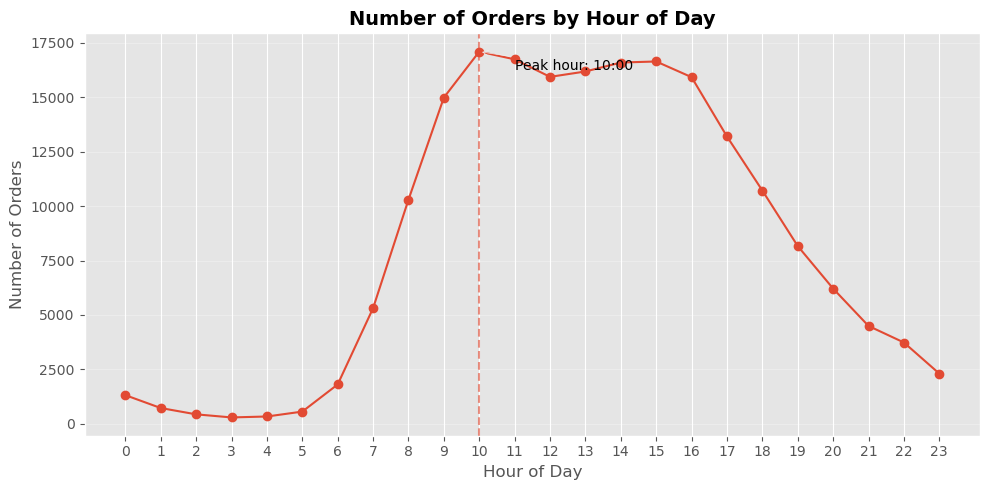

In [12]:
orders_by_hour = (
    df.groupby('order_hour_of_day')['order_id']
    .nunique()
    .sort_index()
)

peak_hour = orders_by_hour.idxmax()
peak_value = orders_by_hour.max()

plt.figure(figsize=(10, 5))
plt.plot(orders_by_hour.index, orders_by_hour.values, marker='o')

plt.title("Number of Orders by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.axvline(peak_hour, linestyle='--', alpha=0.6)

plt.annotate(
    f'Peak hour: {peak_hour}:00',
    xy=(peak_hour, peak_value),
    xytext=(peak_hour + 1, peak_value * 0.95),
    arrowprops=dict(arrowstyle='->')
)

plt.tight_layout()
plt.savefig("02_orders_by_hour.png", dpi=300, bbox_inches='tight')
plt.show()


### Interpretation

Order activity increases significantly after early morning hours, with a clear peak around 10 AM. The majority of orders are concentrated between 9 AM and 3 PM, after which activity gradually declines throughout the evening.

This pattern suggests that customers tend to place orders during daytime hours, likely aligning with daily routines such as meal planning or household organization.

From a business perspective, this concentration of demand during mid-morning and early afternoon hours highlights an opportunity to optimize delivery scheduling, promotional timing, and operational capacity during peak periods.

### Orders by Day of the Week

In this section we analyze how orders are distributed across the days of the week.

Understanding which days have the highest order volume can help identify customer purchasing patterns and peak activity periods.

In [13]:
orders_by_day = (df.groupby('order_dow')['order_id'].nunique())

orders_by_day

order_dow
0    35078
1    34348
2    27277
3    25670
4    24974
5    26557
6    26096
Name: order_id, dtype: int64

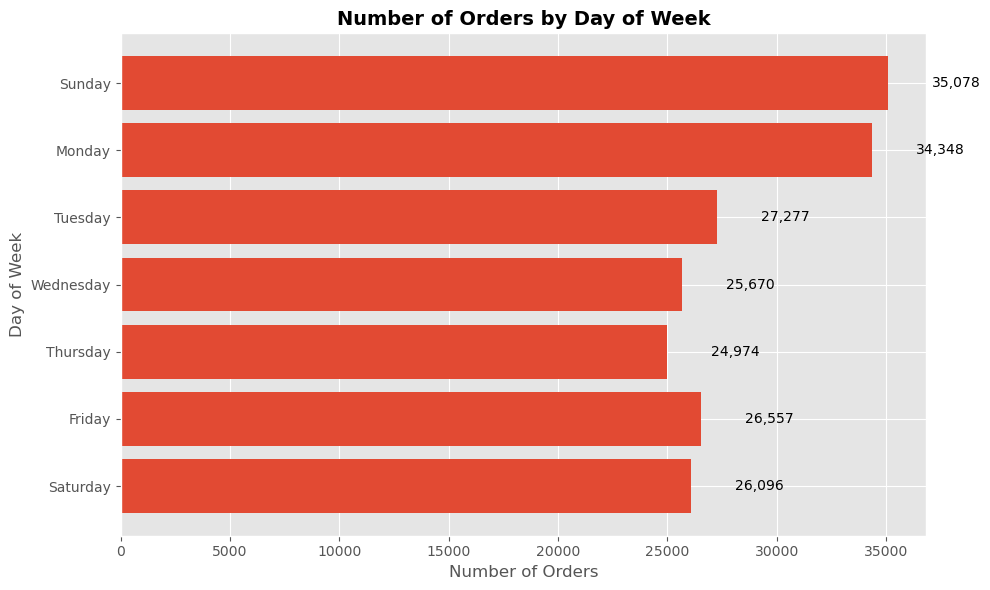

In [14]:
day_mapping = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

orders_by_day = orders_by_day.sort_index()
orders_by_day.index = orders_by_day.index.map(day_mapping)

plt.figure(figsize=(10, 6))

plt.barh(orders_by_day.index, orders_by_day.values)

for i, value in enumerate(orders_by_day.values):
    plt.text(value + 2000, i, f'{value:,}', va='center')

plt.gca().invert_yaxis()

plt.title("Number of Orders by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Number of Orders", fontsize=12)
plt.ylabel("Day of Week", fontsize=12)

plt.tight_layout()
plt.savefig("03_orders_by_day_of_week.png", dpi=300, bbox_inches='tight')
plt.show()


### Interpretation

Order activity varies throughout the week, with noticeable differences between weekdays and weekends.

The results suggest that customers tend to concentrate their purchases on specific days, which may be linked to weekly routines such as grocery planning or restocking.

From a business perspective, understanding these patterns can help optimize promotional campaigns, staffing, and inventory management by aligning resources with peak demand days.

Since the dataset encodes days of the week as numerical values (0–6), these values are mapped to their corresponding day names to improve interpretability.

### Reorder Behavior Analysis

In this section, we analyze how frequently customers reorder products.

Reorder rate is a key indicator of customer loyalty and product stickiness, especially in e-commerce platforms focused on recurring purchases.

In [15]:
overall_reorder_rate = df['reordered'].mean()
print(f"Overall Reorder Rate: {overall_reorder_rate:.2%}")

Overall Reorder Rate: 58.97%


### Interpretation

The overall reorder rate is approximately **59%**, meaning that more than half of all purchased items had already been bought before by the same customers.

This indicates a strong tendency toward repeat purchasing behavior, suggesting that customers frequently return to familiar products rather than constantly exploring new ones.

From a business perspective, this pattern reflects strong customer loyalty and relatively predictable demand, which can support inventory planning, recommendation systems, and retention strategies.

In [16]:
reorder_rate_by_product_type  = df.groupby('product_name')['reordered'].mean().sort_values(ascending = False)
reorder_rate_by_product_type 

product_name
milk                            0.78
water seltzer sparkling water   0.73
fresh fruits                    0.72
eggs                            0.71
soy lactosefree                 0.69
                                ... 
beauty                          0.21
first aid                       0.21
eye ear care                    0.21
baking supplies decor           0.17
spices seasonings               0.15
Name: reordered, Length: 134, dtype: float64

In [17]:
purchase_volume_by_product_type = df.groupby('product_name')['order_id'].count()
purchase_volume_by_product_type

product_name
air fresheners candles            1258
asian foods                      10426
baby accessories                   504
baby bath body care                515
baby food formula                23355
                                 ...  
trash bags liners                 2020
vitamins supplements              2912
water seltzer sparkling water    52564
white wines                       1893
yogurt                           90751
Name: order_id, Length: 134, dtype: int64

In [18]:
product_type_analysis  = pd.concat([reorder_rate_by_product_type , purchase_volume_by_product_type], axis=1)
product_type_analysis.columns = ['reorder_rate', 'purchase_volume']
product_type_analysis 

,reorder_rate,purchase_volume
product_name,,
milk,0.78,55150
water seltzer sparkling water,0.73,52564
fresh fruits,0.72,226039
eggs,0.71,27986
soy lactosefree,0.69,39389
...,...,...
beauty,0.21,387
first aid,0.21,693
eye ear care,0.21,598


In [19]:
reliable_product_type_analysis  = (product_type_analysis[product_type_analysis['purchase_volume'] >= 1000].sort_values(by='reorder_rate', ascending = False))
reliable_product_type_analysis.head(10)

,reorder_rate,purchase_volume
product_name,,
milk,0.78,55150
water seltzer sparkling water,0.73,52564
fresh fruits,0.72,226039
eggs,0.71,27986
soy lactosefree,0.69,39389
packaged produce,0.69,17408
cream,0.69,19786
yogurt,0.69,90751
bread,0.67,36381


### Product Types with the Highest Reorder Rates

The analysis shows that certain product types have significantly higher reorder rates than others, particularly among frequently purchased grocery items.

Products such as **milk, water seltzer, fresh fruits, eggs, and yogurt** exhibit high reorder rates, indicating strong customer loyalty and consistent repurchasing behavior.

To ensure reliable insights, the analysis focuses on product types with a sufficiently high purchase volume, filtering out low-frequency items that could distort the results.

These findings suggest that staple grocery products play a central role in driving repeat purchases on the platform.

From a business perspective, high reorder rates in these categories indicate predictable demand patterns, which can support inventory optimization, personalized recommendations, and targeted retention strategies.

In [20]:
top_reordered_product_types = (
    reliable_product_type_analysis
    .head(10)
    .sort_values(by='reorder_rate', ascending=True)
)

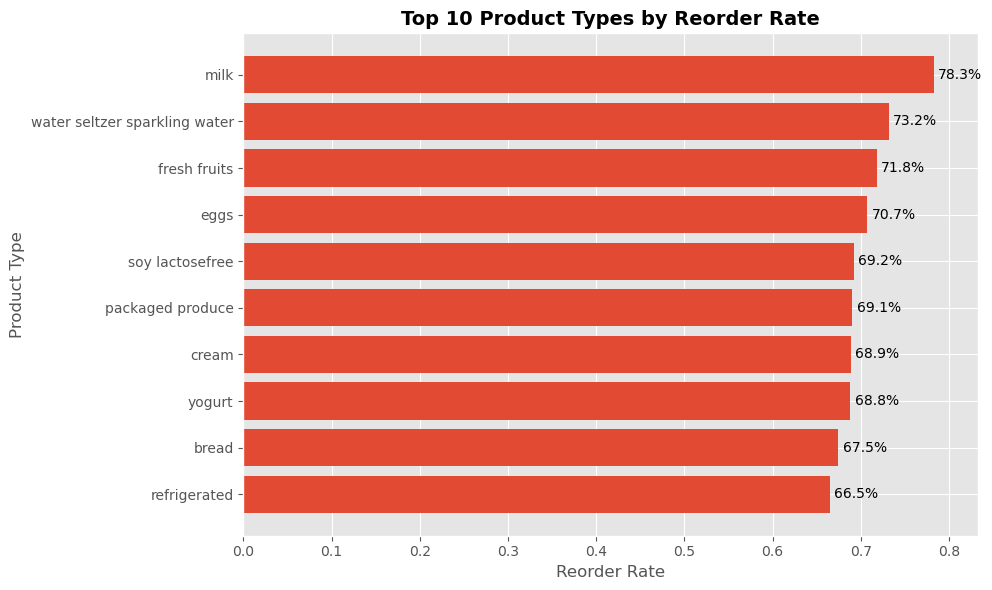

In [21]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_reordered_product_types.index,
    top_reordered_product_types['reorder_rate']
)

for i, value in enumerate(top_reordered_product_types['reorder_rate']):
    plt.text(value + 0.005, i, f'{value:.1%}', va='center')

plt.title("Top 10 Product Types by Reorder Rate", fontsize=14, fontweight="bold")
plt.xlabel("Reorder Rate", fontsize=12)
plt.ylabel("Product Type", fontsize=12)

plt.xlim(0, top_reordered_product_types['reorder_rate'].max() + 0.05)

plt.tight_layout()
plt.savefig("04_reorder_rate_by_product_type.png", dpi=300, bbox_inches='tight')
plt.show()


### Interpretation

The chart highlights the product types with the highest reorder rates among those with significant purchase volume, ensuring that the results are both meaningful and reliable.

The top-ranked items are primarily essential grocery products, such as milk, eggs, fresh fruits, and beverages, which customers tend to purchase regularly as part of their routine shopping behavior.

This reinforces the idea that repeat purchases are driven by necessity rather than impulse, with staple items playing a central role in customer retention.

From a business perspective, these high-performing product types represent key opportunities for demand forecasting, subscription models, and personalized recommendations, as they reflect consistent and predictable purchasing patterns.

### Basket Size Analysis

In this section, we analyze how many products customers typically purchase per order.

Basket size is an important metric in e-commerce, as it reflects customer purchasing behavior and directly impacts revenue per transaction.

In [22]:
basket_size = (df.groupby("order_id")["product_id"].count())

basket_size.head()

order_id
10    15
11     5
28    16
38     9
56    10
Name: product_id, dtype: int64

In [23]:
average_basket_size = basket_size.mean()
median_basket_size = basket_size.median()

print(f"Average basket size: {average_basket_size:.2f}")
print(f"Median basket size: {median_basket_size:.2f}")

Average basket size: 10.10
Median basket size: 8.00


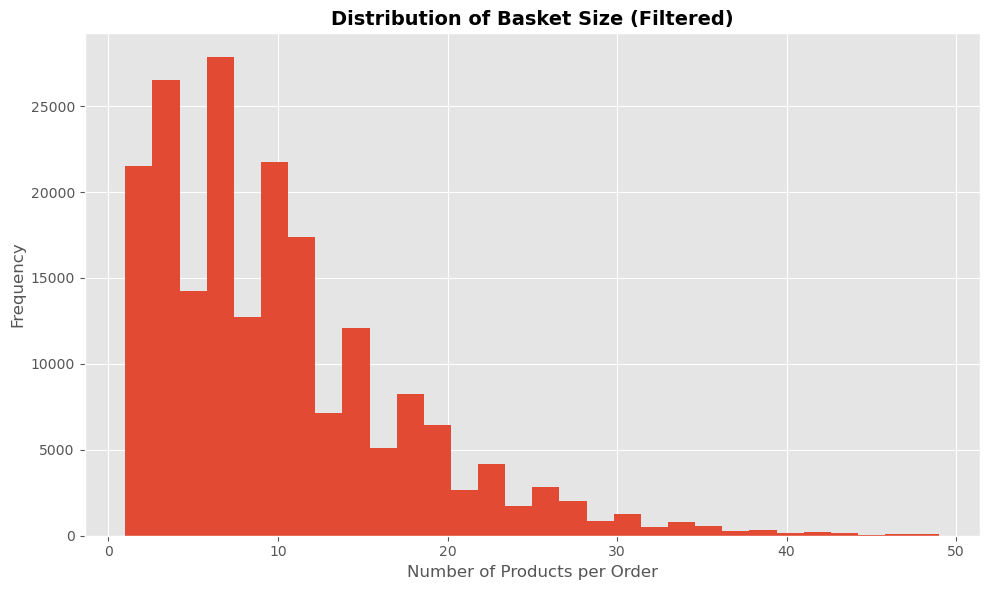

In [25]:
plt.figure(figsize=(10,6))
plt.hist(basket_size[basket_size < 50], bins=30)

plt.title("Distribution of Basket Size (Filtered)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Products per Order", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.savefig("05_basket_size_distribution_filtered.png", dpi=300, bbox_inches='tight')
plt.show()


### Interpretation

The analysis shows that the average number of products per order is relatively moderate, indicating that customers typically purchase multiple items in each transaction rather than single products.

The distribution is right-skewed, with most orders containing a small to medium number of items, and fewer orders with very large basket sizes.

This suggests that while most customers make routine purchases with a limited number of products, there are occasional larger orders that may correspond to bulk purchases or restocking behavior.

From a business perspective, understanding basket size is essential for optimizing pricing strategies, bundling offers, and cross-selling opportunities, as increasing the number of items per order can significantly impact overall revenue.

## Key Business Insights

### Key Findings

1. **Customer orders are highly concentrated during daytime hours, with a peak around mid-morning.**  
   This suggests that users tend to place orders as part of their daily routines, creating opportunities to optimize delivery scheduling and promotional timing during high-demand periods.

2. **Fresh grocery items dominate purchasing behavior, particularly fruits, vegetables, dairy, and beverages.**  
   This indicates that the platform is primarily used for recurring grocery shopping rather than occasional purchases, making inventory availability in these categories critical for customer satisfaction.

3. **Reorder rates are consistently high across essential product types, reflecting strong customer loyalty.**  
   Frequently purchased items such as milk, eggs, and fresh produce show particularly high reorder rates, suggesting predictable demand patterns and opportunities for personalized recommendations.

4. **Repeat purchases are driven by staple products with both high reorder rates and high purchase volume.**  
   This combination highlights key product segments that are central to customer retention and should be prioritized in inventory planning and recommendation systems.

5. **Customers typically purchase multiple items per order, indicating moderate basket sizes.**  
   This behavior suggests opportunities for cross-selling strategies and bundling offers to increase average order value.

6. **Purchasing behavior follows consistent weekly and daily patterns.**  
   Understanding these patterns can help businesses align marketing campaigns, staffing, and logistics operations with peak demand periods.

## Conclusion

This analysis provides a comprehensive overview of customer purchasing behavior in an e-commerce environment.

The results highlight strong repeat purchasing patterns, predictable demand in essential product categories, and clear temporal trends in customer activity.

These insights can support more effective decision-making in inventory management, marketing strategy, and customer retention.